### Markov decision process

This week's methods are all built to solve __M__arkov __D__ecision __P__rocesses. In the broadest sense, an MDP is defined by how it changes states and how rewards are computed.

State transition is defined by $P(s' |s,a)$ - how likely are you to end at state $s'$ if you take action $a$ from state $s$. Now there's more than one way to define rewards, but we'll use $r(s,a,s')$ function for convenience.

_This notebook is inspired by the awesome_ [CS294](https://github.com/berkeleydeeprlcourse/homework/blob/36a0b58261acde756abd55306fbe63df226bf62b/hw2/HW2.ipynb) _by Berkeley_

For starters, let's define a simple MDP from this picture:

<img src="https://upload.wikimedia.org/wikipedia/commons/a/ad/Markov_Decision_Process.svg" width="400px" alt="Diagram by Waldoalvarez via Wikimedia Commons, CC BY-SA 4.0"/>

In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week02_value_based/mdp.py
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [2]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


We can now use MDP just as any other gym environment:

In [3]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

initial state = s0
next_state = s2, reward = 0.0, done = False


but it also has other methods that you'll need for Value Iteration

In [4]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ", mdp.get_transition_prob('s1', 'a0', 's0'))

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


### Optional: Visualizing MDPs

You can also visualize any MDP with the drawing fuction donated by [neer201](https://github.com/neer201).

You have to install graphviz for system and for python. 

1. * For ubuntu just run: `sudo apt-get install graphviz` 
   * For OSX: `brew install graphviz`
2. `pip install graphviz`
3. restart the notebook

__Note:__ Installing graphviz on some OS (esp. Windows) may be tricky. However, you can ignore this part alltogether and use the standart vizualization.

In [5]:
from mdp import has_graphviz
from IPython.display import display
print("Graphviz available:", has_graphviz)

Graphviz available: True


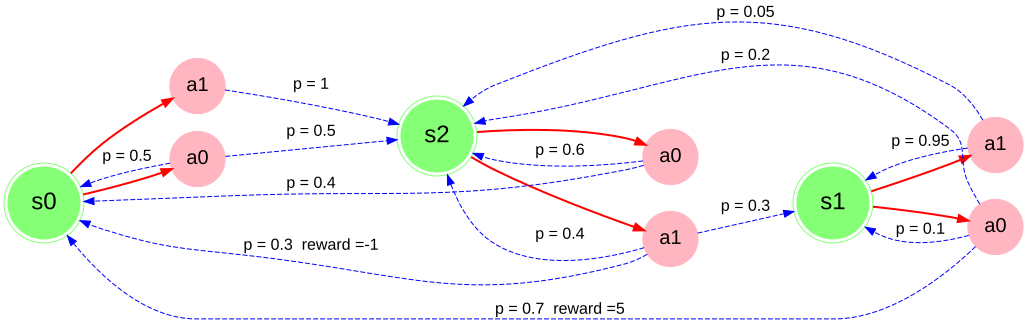

In [6]:
if has_graphviz:
    from mdp import plot_graph, plot_graph_with_state_values, plot_graph_optimal_strategy_and_state_values
    display(plot_graph(mdp))

### Value Iteration

Now let's build something to solve this MDP. The simplest algorithm so far is __V__alue __I__teration

Here's the pseudo-code for VI:

---

`1.` Initialize $V^{(0)}(s)=0$, for all $s$

`2.` For $i=0, 1, 2, \dots$
 
`3.` $ \quad V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$, for all $s$

---

First, let's write a function to compute the state-action value function $Q^{\pi}$, defined as follows

$$Q_i(s, a) = \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$$


In [7]:
def get_action_value(mdp, state_values, state, action, gamma):
    """ Computes Q(s,a) as in formula above """
    q = 0
    for s in state_values.keys():
        prob_per = mdp.get_transition_prob(state, action, s)
        reward = mdp.get_reward(state, action, s)
        q += prob_per * (reward + gamma * state_values[s])

    return q

In [8]:
import numpy as np
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

Using $Q(s,a)$ we can now define the "next" V(s) for value iteration.
 $$V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \max_a Q_i(s,a)$$

In [9]:
def get_new_state_value(mdp, state_values, state, gamma):
    """ Computes next V(s) as in formula above. Please do not change state_values in process. """
    if mdp.is_terminal(state):
        return 0
    best_action_value = -float('inf')
    for action in mdp.get_possible_actions(state):
        action_value = get_action_value(mdp, state_values, state, action, gamma)
        if action_value > best_action_value:
            best_action_value = action_value
    
    return best_action_value

In [10]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's2', 0.9), 1.08)
assert np.isclose(get_new_state_value(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9), -13500000000.0), \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert test_Vs == test_Vs_copy, "Please do not change state_values in get_new_state_value"

Finally, let's combine everything we wrote into a working value iteration algo.

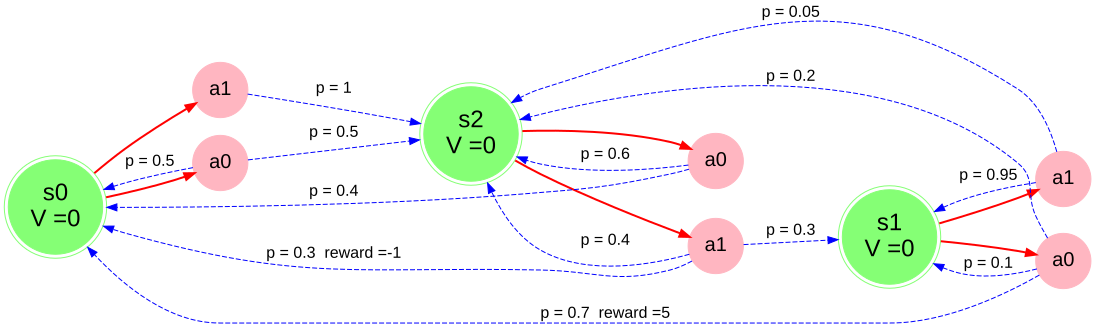

iter    0   |   diff: 3.50000   |   V(s0) = 0.000   V(s1) = 0.000   V(s2) = 0.000
iter    1   |   diff: 0.64500   |   V(s0) = 0.000   V(s1) = 3.500   V(s2) = 0.000
iter    2   |   diff: 0.58050   |   V(s0) = 0.000   V(s1) = 3.815   V(s2) = 0.645
iter    3   |   diff: 0.43582   |   V(s0) = 0.581   V(s1) = 3.959   V(s2) = 0.962
iter    4   |   diff: 0.30634   |   V(s0) = 0.866   V(s1) = 4.395   V(s2) = 1.272
iter    5   |   diff: 0.27571   |   V(s0) = 1.145   V(s1) = 4.670   V(s2) = 1.579
iter    6   |   diff: 0.24347   |   V(s0) = 1.421   V(s1) = 4.926   V(s2) = 1.838
iter    7   |   diff: 0.21419   |   V(s0) = 1.655   V(s1) = 5.169   V(s2) = 2.075
iter    8   |   diff: 0.19277   |   V(s0) = 1.868   V(s1) = 5.381   V(s2) = 2.290
iter    9   |   diff: 0.17327   |   V(s0) = 2.061   V(s1) = 5.573   V(s2) = 2.481
iter   10   |   diff: 0.15569   |   V(s0) = 2.233   V(s1) = 5.746   V(s2) = 2.654
iter   11   |   diff: 0.14012   |   V(s0) = 2.389   V(s1) = 5.902   V(s2) = 2.810
iter   12   |   

In [11]:
# parameters
gamma = 0.9            # discount for MDP
num_iter = 100         # maximum iterations, excluding initialization
# stop VI if new values are this close to old values (or closer)
min_difference = 0.001

# initialize V(s)
state_values = {s: 0 for s in mdp.get_all_states()}

if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

for i in range(num_iter):

    # Compute new state values using the functions you defined above.
    # It must be a dict {state : float V_new(state)}
    new_state_values = {s: get_new_state_value(mdp, state_values, s, gamma) for s in mdp.get_all_states()}

    assert isinstance(new_state_values, dict)

    # Compute difference
    diff = max(abs(new_state_values[s] - state_values[s])
               for s in mdp.get_all_states())
    print("iter %4i   |   diff: %6.5f   |   " % (i, diff), end="")
    print('   '.join("V(%s) = %.3f" % (s, v) for s, v in state_values.items()))
    state_values = new_state_values

    if diff < min_difference:
        print("Terminated")
        break

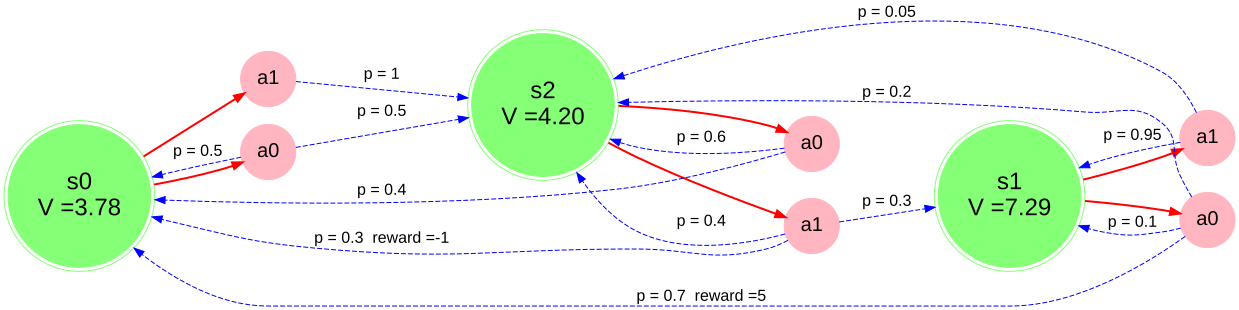

In [12]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

In [13]:
print("Final state values:", state_values)

assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

Final state values: {'s0': 3.7810348735476405, 's1': 7.294006423867229, 's2': 4.202140275227048}


Now let's use those $V^{*}(s)$ to find optimal actions in each state

 $$\pi^*(s) = argmax_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = argmax_a Q_i(s,a)$$
 
The only difference vs V(s) is that here we take not max but argmax: find action such with maximum Q(s,a).

In [14]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    """ Finds optimal action using formula above. """
    if mdp.is_terminal(state):
        return None
    
    pi = []
    for action in mdp.get_possible_actions(state):
        action_value = get_action_value(mdp, state_values, state, action, gamma)
        pi.append((action_value, action))

    return max(pi)[1]

In [15]:
assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'

assert get_optimal_action(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9) == 'a0', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert get_optimal_action(mdp, {'s0': -2e10, 's1': 0, 's2': -1e10}, 's0', 0.9) == 'a1', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"

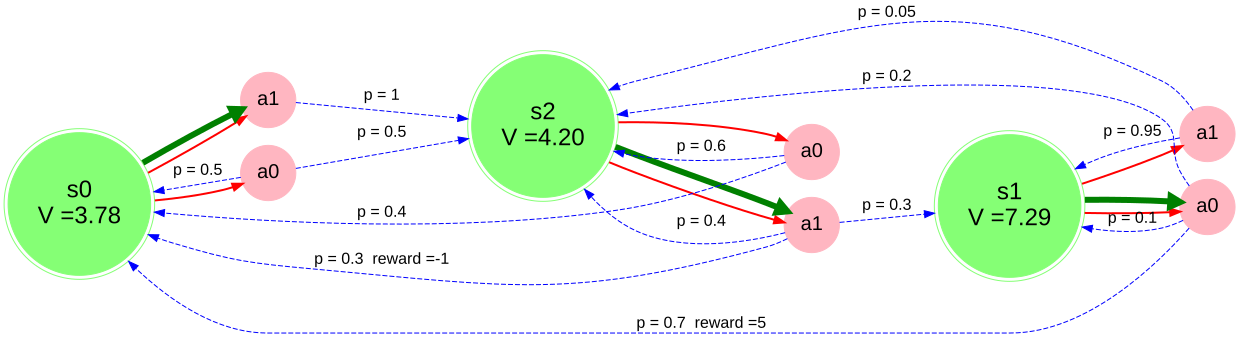

In [16]:
if has_graphviz:
    display(plot_graph_optimal_strategy_and_state_values(mdp, state_values, get_action_value))

In [17]:
# Measure agent's average reward

s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
    rewards.append(r)

print("average reward: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

average reward:  0.4638


### Frozen lake

In [18]:
from mdp import FrozenLakeEnv
mdp = FrozenLakeEnv(slip_chance=0)

mdp.render()

*FFF
FHFH
FFFH
HFFG



In [19]:
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ performs num_iter value iteration steps starting from state_values. Same as before but in a function """
    state_values = state_values or {s: 0 for s in mdp.get_all_states()}
    for i in range(num_iter):

        # Compute new state values using the functions you defined above. It must be a dict {state : new_V(state)}
        new_state_values = {s: get_new_state_value(mdp, state_values, s, gamma) for s in mdp.get_all_states()}
        assert isinstance(new_state_values, dict)

        # Compute difference
        diff = max(abs(new_state_values[s] - state_values[s])
                   for s in mdp.get_all_states())

        print("iter %4i   |   diff: %6.5f   |   V(start): %.3f " %
              (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            break

    return state_values

In [20]:
state_values = value_iteration(mdp)

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 


In [21]:
s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, gamma)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

*FFF
FHFH
FFFH
HFFG

right

S*FF
FHFH
FFFH
HFFG

right

SF*F
FHFH
FFFH
HFFG

down

SFFF
FH*H
FFFH
HFFG

down

SFFF
FHFH
FF*H
HFFG

down

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*



### Let's visualize!

It's usually interesting to see what your algorithm actually learned under the hood. To do so, we'll plot state value functions and optimal actions at each VI step.

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline


def draw_policy(mdp, state_values):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}
    plt.imshow(V.reshape(w, h), cmap='gray', interpolation='none', clim=(0, 1))
    ax = plt.gca()
    ax.set_xticks(np.arange(h)-.5)
    ax.set_yticks(np.arange(w)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (0, 1)}
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12,  verticalalignment='center',
                     horizontalalignment='center', fontweight='bold')
            a = Pi[y, x]
            if a is None:
                continue
            u, v = a2uv[a]
            plt.arrow(x, y, u*.3, -v*.3, color='m',
                      head_width=0.1, head_length=0.1)
    plt.grid(color='b', lw=2, ls='-')
    plt.show()

after iteration 0
iter    0   |   diff: 1.00000   |   V(start): 0.000 


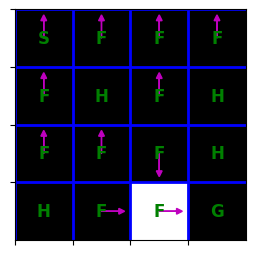

after iteration 1
iter    0   |   diff: 0.90000   |   V(start): 0.000 


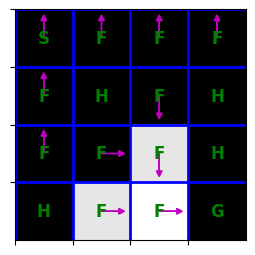

after iteration 2
iter    0   |   diff: 0.81000   |   V(start): 0.000 


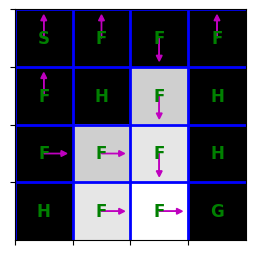

after iteration 3
iter    0   |   diff: 0.72900   |   V(start): 0.000 


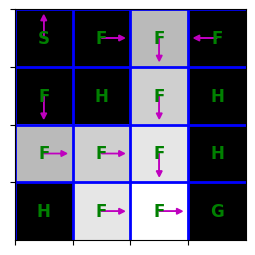

after iteration 4
iter    0   |   diff: 0.65610   |   V(start): 0.000 


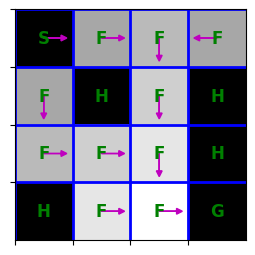

after iteration 5
iter    0   |   diff: 0.59049   |   V(start): 0.590 


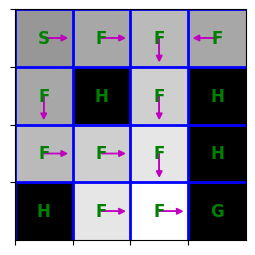

after iteration 6
iter    0   |   diff: 0.00000   |   V(start): 0.590 


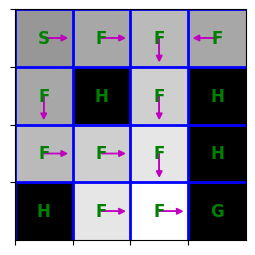

after iteration 7
iter    0   |   diff: 0.00000   |   V(start): 0.590 


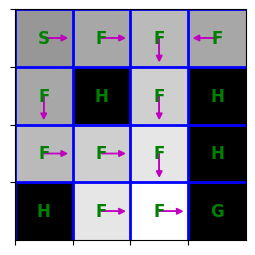

after iteration 8
iter    0   |   diff: 0.00000   |   V(start): 0.590 


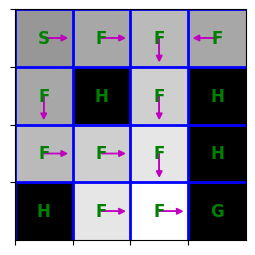

after iteration 9
iter    0   |   diff: 0.00000   |   V(start): 0.590 


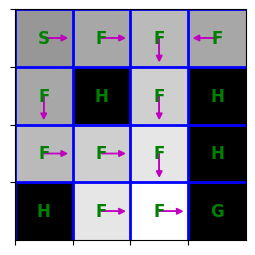

In [23]:
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(10):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
# please ignore iter 0 at each step

after iteration 29
iter    0   |   diff: 0.00000   |   V(start): 0.198 


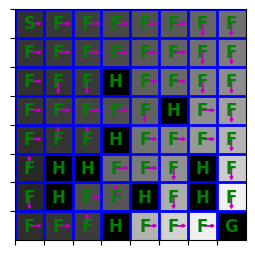

In [24]:
from IPython.display import clear_output
from time import sleep
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(30):
    clear_output(True)
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)
# please ignore iter 0 at each step

Massive tests

In [25]:
mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 
average reward:  1.0
Well done!


In [26]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

iter    0   |   diff: 0.90000   |   V(start): 0.000 
iter    1   |   diff: 0.72900   |   V(start): 0.000 
iter    2   |   diff: 0.62330   |   V(start): 0.000 
iter    3   |   diff: 0.50487   |   V(start): 0.000 
iter    4   |   diff: 0.40894   |   V(start): 0.000 
iter    5   |   diff: 0.34868   |   V(start): 0.349 
iter    6   |   diff: 0.06529   |   V(start): 0.410 
iter    7   |   diff: 0.05832   |   V(start): 0.468 
iter    8   |   diff: 0.01139   |   V(start): 0.480 
iter    9   |   diff: 0.00764   |   V(start): 0.487 
iter   10   |   diff: 0.00164   |   V(start): 0.489 
iter   11   |   diff: 0.00094   |   V(start): 0.490 
iter   12   |   diff: 0.00022   |   V(start): 0.490 
iter   13   |   diff: 0.00011   |   V(start): 0.490 
iter   14   |   diff: 0.00003   |   V(start): 0.490 
iter   15   |   diff: 0.00001   |   V(start): 0.490 
iter   16   |   diff: 0.00000   |   V(start): 0.490 
average reward:  0.889
Well done!


In [27]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Well done!")

iter    0   |   diff: 0.75000   |   V(start): 0.000 
iter    1   |   diff: 0.50625   |   V(start): 0.000 
iter    2   |   diff: 0.39867   |   V(start): 0.000 
iter    3   |   diff: 0.26910   |   V(start): 0.000 
iter    4   |   diff: 0.18164   |   V(start): 0.000 
iter    5   |   diff: 0.14013   |   V(start): 0.140 
iter    6   |   diff: 0.07028   |   V(start): 0.199 
iter    7   |   diff: 0.06030   |   V(start): 0.260 
iter    8   |   diff: 0.02594   |   V(start): 0.285 
iter    9   |   diff: 0.01918   |   V(start): 0.305 
iter   10   |   diff: 0.00858   |   V(start): 0.313 
iter   11   |   diff: 0.00560   |   V(start): 0.319 
iter   12   |   diff: 0.00260   |   V(start): 0.321 
iter   13   |   diff: 0.00159   |   V(start): 0.323 
iter   14   |   diff: 0.00076   |   V(start): 0.324 
iter   15   |   diff: 0.00045   |   V(start): 0.324 
iter   16   |   diff: 0.00022   |   V(start): 0.324 
iter   17   |   diff: 0.00012   |   V(start): 0.325 
iter   18   |   diff: 0.00006   |   V(start): 

In [28]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

iter    0   |   diff: 0.80000   |   V(start): 0.000 
iter    1   |   diff: 0.57600   |   V(start): 0.000 
iter    2   |   diff: 0.41472   |   V(start): 0.000 
iter    3   |   diff: 0.29860   |   V(start): 0.000 
iter    4   |   diff: 0.24186   |   V(start): 0.000 
iter    5   |   diff: 0.19349   |   V(start): 0.000 
iter    6   |   diff: 0.15325   |   V(start): 0.000 
iter    7   |   diff: 0.12288   |   V(start): 0.000 
iter    8   |   diff: 0.09930   |   V(start): 0.000 
iter    9   |   diff: 0.08037   |   V(start): 0.000 
iter   10   |   diff: 0.06426   |   V(start): 0.000 
iter   11   |   diff: 0.05129   |   V(start): 0.000 
iter   12   |   diff: 0.04330   |   V(start): 0.000 
iter   13   |   diff: 0.03802   |   V(start): 0.033 
iter   14   |   diff: 0.03332   |   V(start): 0.058 
iter   15   |   diff: 0.02910   |   V(start): 0.087 
iter   16   |   diff: 0.01855   |   V(start): 0.106 
iter   17   |   diff: 0.01403   |   V(start): 0.120 
iter   18   |   diff: 0.00810   |   V(start): 

# HW Part 1: Value iteration convergence

### Find an MDP for which value iteration takes long to converge  (1 pts)

When we ran value iteration on the small frozen lake problem, the last iteration where an action changed was iteration 6--i.e., value iteration computed the optimal policy at iteration 6. Are there any guarantees regarding how many iterations it'll take value iteration to compute the optimal policy? There are no such guarantees without additional assumptions--we can construct the MDP in such a way that the greedy policy will change after arbitrarily many iterations.

Your task: define an MDP with at most 3 states and 2 actions, such that when you run value iteration, the optimal action changes at iteration >= 50. Use discount=0.95. (However, note that the discount doesn't matter here--you can construct an appropriate MDP with any discount.)

Note: value function must change at least once after iteration >=50, not necessarily change on every iteration till >=50.

In [29]:
transition_probs = {
    's0': {
        'a0': {'s1': 1.0},
        'a1': {'s2': 1.0}
    },
    's1': {
        'a0': {'s1': 1.0},
        'a1': {'s1': 1.0}
    },
    's2': {
        'a0': {'s2': 1.0},
        'a1': {'s2': 1.0} 
    }
}

rewards = {
    's0': {
        'a1': {'s2': 17.5}
    },
    's1': {
        'a0': {'s1': 1.0},
        'a1': {'s1': 1.0}
    }
}

from mdp import MDP
from numpy import random
mdp = MDP(transition_probs, rewards, initial_state=random.choice(tuple(transition_probs.keys())))

In [30]:
state_values = {s: 0 for s in mdp.get_all_states()}
policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                   for state in sorted(mdp.get_all_states())])

for i in range(100):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)

    new_policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                           for state in sorted(mdp.get_all_states())])

    n_changes = (policy != new_policy).sum()
    print("N actions changed = %i \n" % n_changes)
    policy = new_policy


after iteration 0
iter    0   |   diff: 17.50000   |   V(start): 1.000 
N actions changed = 0 

after iteration 1
iter    0   |   diff: 0.90000   |   V(start): 1.900 
N actions changed = 0 

after iteration 2
iter    0   |   diff: 0.81000   |   V(start): 2.710 
N actions changed = 0 

after iteration 3
iter    0   |   diff: 0.72900   |   V(start): 3.439 
N actions changed = 0 

after iteration 4
iter    0   |   diff: 0.65610   |   V(start): 4.095 
N actions changed = 0 

after iteration 5
iter    0   |   diff: 0.59049   |   V(start): 4.686 
N actions changed = 0 

after iteration 6
iter    0   |   diff: 0.53144   |   V(start): 5.217 
N actions changed = 0 

after iteration 7
iter    0   |   diff: 0.47830   |   V(start): 5.695 
N actions changed = 0 

after iteration 8
iter    0   |   diff: 0.43047   |   V(start): 6.126 
N actions changed = 0 

after iteration 9
iter    0   |   diff: 0.38742   |   V(start): 6.513 
N actions changed = 0 

after iteration 10
iter    0   |   diff: 0.34868 

### Value iteration convervence proof (1 pts)
**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

Update of value function in value iteration can be rewritten in a form of Bellman operator:

$$(TV)(s) = \max_{a \in \mathcal{A}}\mathbb{E}\left[ r_{t+1} + \gamma V(s_{t+1}) | s_t = s, a_t = a\right]$$

Value iteration algorithm with Bellman operator:

---
&nbsp;&nbsp; Initialize $V_0$

&nbsp;&nbsp; **for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; $V_{k+1} \leftarrow TV_k$

&nbsp;&nbsp;**end for**

---

In [lecture](https://docs.google.com/presentation/d/1lz2oIUTvd2MHWKEQSH8hquS66oe4MZ_eRvVViZs2uuE/edit#slide=id.g4fd6bae29e_2_4) we established contraction property of bellman operator:

$$
||TV - TU||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

Using contraction property of Bellman operator, Banach fixed-point theorem and Bellman equations prove that value function converges to $V^*$ in value iterateion$

### Доказательство:

На нашем пространстве заданя норма $\|U-V\|_{\infty}=max_{s \in S}|U(s) - V(s)|$

0. На лекции выяснили, что $T = max E[r_{t+1} + \gamma V(s_{t+1}) |s_t=s, a_t=a]$ сжимающее отображение, это важно для теоремы банаха.

1. $\gamma \in (0; 1); ||TV - TU||_{\infty} \le \gamma ||V - U||_{\infty} \Rightarrow$ по теореме Банаха о точке сжатия $\exists V*: TV* = V*, \forall \{V_k\}: V_{k+1} = T(V_k), lim_{k\rightarrow \infty} V_k = V*$, те единственность существования такой точки. 

2. Это значит, что итеративно мы как бы и выполняем то, что написано в пределе теоремы, подставляя в T оператор наш вектор, те наши итерации и формируют эту последовательность в результате чего мы получаем общую точку сходимости, и тк это для любой последовательности, то можно начинать с 0.

### Asynchronious value iteration (2 pts)

Consider the following algorithm:

---

Initialize $V_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Select some state $s_k \in \mathcal{S}$    

&nbsp;&nbsp;&nbsp;&nbsp; $V(s_k) := (TV)(s_k)$

**end for**

---


Note that unlike common value iteration, here we update only a single state at a time.

**Homework.** Prove the following proposition:

If for all $s \in \mathcal{S}$, $s$ appears in the sequence $(s_0, s_1, ...)$ infinitely often, then $V$ converges to $V*$

### Доказательство

Обозначим глобальную максимальную ошибку на шаге $k$ как $e_k = \|V_k - V^*\|_\infty = \max_{s \in S} |V_k(s) - V^*(s)|$.

1. $e_k$ никогда не возрастает 
На каждом шаге $k$ мы обновляем только одно состояние $s_k$. Для состояний $s \neq s_k$ значения не меняются, поэтому их ошибка остается прежней (она $\le e_k$). Для обновляемого состояния $s_k$ новая ошибка составит:
$|V_{k+1}(s_k) - V^*(s_k)| = |T(V_k)(s_k) - T(V^*)(s_k)| \le \|TV_k - TV^*\|_\infty \le \gamma \|V_k - V^*\|_\infty = \gamma e_k$.
Так как $\gamma \in [0, 1)$, ошибка для $s_k$ строго меньше $e_k$. В итоге ни для одного из состояний ошибка не превысила $e_k$, следовательно, новая максимальная ошибка $e_{k+1} \le e_k$.

2. Разбиение на эпохи. По условию каждое состояние появляется в последовательности бесконечно часто. Это значит, что мы можем разбить последовательность шагов на конечные эпохи так, чтобы за одну эпоху каждое состояние $s \in S$ было обновлено хотя бы один раз.

3. Сжатие ошибки к 0, рассмотрим одну такую эпоху. Пусть в ее начале максимальная ошибка была $E_0$. Так как ошибка не возрастает, в любой момент времени внутри эпохи глобальная ошибка $\le E_0$. В момент последнего обновления любого состояния s внутри этой эпохи, его новая ошибка будет $\le \gamma \cdot (\text{ошибка на момент обновления}) \le \gamma E_0$.
Поскольку к концу эпохи так обновятся все состояния, глобальная максимальная ошибка к концу эпохи гарантированно сожмется: $E_{конец} \le \gamma E_0$.
Через m таких эпох ошибка составит не более $E_0 \cdot \gamma^m$. Так как эпох бесконечно много ($m \to \infty$) и $\gamma < 1$, предел ошибки равен 0: $\lim_{m \to \infty} E_0 \cdot \gamma^m = 0$. 
Значит, $V_k$ сходится к точке равновесия $V^*$

# HW Part 2: Policy iteration

## Policy iteration implementateion (3 pts)

Let's implement exact policy iteration (PI), which has the following pseudocode:

---
Initialize $\pi_0$   `// random or fixed action`

For $n=0, 1, 2, \dots$
- Compute the state-value function $V^{\pi_{n}}$
- Using $V^{\pi_{n}}$, compute the state-action-value function $Q^{\pi_{n}}$
- Compute new policy $\pi_{n+1}(s) = \operatorname*{argmax}_a Q^{\pi_{n}}(s,a)$
---

Unlike VI, policy iteration has to maintain a policy - chosen actions from all states - and estimate $V^{\pi_{n}}$ based on this policy. It only changes policy once values converged.


Below are a few helpers that you may or may not use in your implementation.

In [31]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's1': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

Let's write a function called `compute_vpi` that computes the state-value function $V^{\pi}$ for an arbitrary policy $\pi$.

Unlike VI, this time you must find the exact solution, not just a single iteration.

Recall that $V^{\pi}$ satisfies the following linear equation:
$$V^{\pi}(s) = \sum_{s'} P(s,\pi(s),s')[ R(s,\pi(s),s') + \gamma V^{\pi}(s')]$$

You'll have to solve a linear system in your code. (Find an exact solution, e.g., with `np.linalg.solve`.)

In [32]:
def compute_vpi(mdp, policy, gamma):
    states = mdp.get_all_states()
    B = [0] * len(states)
    P = [[0] * len(states) for _ in states]
    for i, s in enumerate(states):
        if mdp.is_terminal(s):
            B[i] = 0
        else:
            a = policy[s]
            
            for s1 in mdp.get_next_states(s, a):
                B[i] += mdp.get_reward(s, a, s1) * mdp.get_transition_prob(s, a, s1)
                P[i][states.index(s1)] += mdp.get_transition_prob(s, a, s1)

    V_new = (np.linalg.inv(np.eye(len(states)) - gamma * np.array(P)) @ np.array(B))
    return {s: V_new[i] for i, s in enumerate(states)}

In [33]:
test_policy = {s: np.random.choice(
    mdp.get_possible_actions(s)) for s in mdp.get_all_states()}
new_vpi = compute_vpi(mdp, test_policy, gamma)

print(new_vpi)

assert type(
    new_vpi) is dict, "compute_vpi must return a dict {state : V^pi(state) for all states}"

{'s0': np.float64(0.0), 's1': np.float64(0.0), 's2': np.float64(0.0)}


Once we've got new state values, it's time to update our policy.

In [34]:
def compute_new_policy(mdp, vpi, gamma):
    """
    Computes new policy as argmax of state values
    :param vpi: a dict {state : V^pi(state) for all states}
    :returns: a dict {state : optimal action for all states}
    """
    q = {}
    for s in mdp.get_all_states():
        for a in mdp.get_possible_actions(s):
            q[s, a] = get_action_value(mdp, vpi, s, a, gamma)
    new_policy = {}
    for s in mdp.get_all_states():
        best_action = None
        best_q = -float('inf')
        for a in mdp.get_possible_actions(s):
            if q[s, a] > best_q:
                best_q = q[s, a]
                best_action = a
        new_policy[s] = best_action
    return new_policy

In [35]:
new_policy = compute_new_policy(mdp, new_vpi, gamma)

print(new_policy)

assert type(
    new_policy) is dict, "compute_new_policy must return a dict {state : optimal action for all states}"

{'s0': 'a0', 's1': 'a0', 's2': 'a0'}


__Main loop__

In [36]:
def policy_iteration(mdp, policy=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    if policy is None:
        policy = {}
        for s in mdp.get_all_states():
            actions = mdp.get_possible_actions(s)
            policy[s] = np.random.choice(actions) if actions else None

    state_values = {s: 0 for s in mdp.get_all_states()}
    
    for i in range(num_iter):
        state_values = compute_vpi(mdp, policy, gamma)

        new_policy = compute_new_policy(mdp, state_values, gamma)
        
        n_changes = np.sum(policy != new_policy)
        print("iter %4i   |   N actions changed = %i \n" % (i, n_changes))
        
        policy = new_policy
        
        if n_changes == 0:
            print("Terminated")
            break

    return state_values, policy

__Your PI Results__

In [37]:
transition_probs = {
    's0': {
        'a0': {'s1': 1.0},
        'a1': {'s2': 1.0}
    },
    's1': {
        'a0': {'s1': 1.0},
        'a1': {'s1': 1.0}
    },
    's2': {
        'a0': {'s2': 1.0},
        'a1': {'s2': 1.0} 
    }
}

rewards = {
    's0': {
        'a1': {'s2': 17.5}
    },
    's1': {
        'a0': {'s1': 1.0},
        'a1': {'s1': 1.0}
    }
}


In [38]:
def get_value_iteration_solution(mdp, gamma=0.9):
    state_values = {s: 0 for s in mdp.get_all_states()}
    policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                    for state in sorted(mdp.get_all_states())])

    for i in range(100):
        print("after iteration %i" % i)
        state_values = value_iteration(mdp, state_values, num_iter=1)

        new_policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                            for state in sorted(mdp.get_all_states())])

        n_changes = (policy != new_policy).sum()
        print("N actions changed = %i \n" % n_changes)
        policy = new_policy

    return state_values, policy

def get_policy_iteration_solution(mdp, gamma=0.9):
    return policy_iteration(mdp, gamma=gamma)

mdp = MDP(transition_probs, rewards, initial_state=random.choice(tuple(transition_probs.keys())))


In [39]:
mdp.reset()
get_policy_iteration_solution(mdp)

iter    0   |   N actions changed = 1 

iter    1   |   N actions changed = 0 

Terminated


({'s0': np.float64(17.5),
  's1': np.float64(10.000000000000002),
  's2': np.float64(0.0)},
 {'s0': 'a1', 's1': 'a0', 's2': 'a0'})

In [40]:
mdp.reset()
get_value_iteration_solution(mdp)

after iteration 0
iter    0   |   diff: 17.50000   |   V(start): 1.000 
N actions changed = 0 

after iteration 1
iter    0   |   diff: 0.90000   |   V(start): 1.900 
N actions changed = 0 

after iteration 2
iter    0   |   diff: 0.81000   |   V(start): 2.710 
N actions changed = 0 

after iteration 3
iter    0   |   diff: 0.72900   |   V(start): 3.439 
N actions changed = 0 

after iteration 4
iter    0   |   diff: 0.65610   |   V(start): 4.095 
N actions changed = 0 

after iteration 5
iter    0   |   diff: 0.59049   |   V(start): 4.686 
N actions changed = 0 

after iteration 6
iter    0   |   diff: 0.53144   |   V(start): 5.217 
N actions changed = 0 

after iteration 7
iter    0   |   diff: 0.47830   |   V(start): 5.695 
N actions changed = 0 

after iteration 8
iter    0   |   diff: 0.43047   |   V(start): 6.126 
N actions changed = 0 

after iteration 9
iter    0   |   diff: 0.38742   |   V(start): 6.513 
N actions changed = 0 

after iteration 10
iter    0   |   diff: 0.34868 

N actions changed = 0 

after iteration 62
iter    0   |   diff: 0.00146   |   V(start): 9.987 
N actions changed = 0 

after iteration 63
iter    0   |   diff: 0.00131   |   V(start): 9.988 
N actions changed = 0 

after iteration 64
iter    0   |   diff: 0.00118   |   V(start): 9.989 
N actions changed = 0 

after iteration 65
iter    0   |   diff: 0.00106   |   V(start): 9.990 
N actions changed = 0 

after iteration 66
iter    0   |   diff: 0.00096   |   V(start): 9.991 
N actions changed = 0 

after iteration 67
iter    0   |   diff: 0.00086   |   V(start): 9.992 
N actions changed = 0 

after iteration 68
iter    0   |   diff: 0.00077   |   V(start): 9.993 
N actions changed = 0 

after iteration 69
iter    0   |   diff: 0.00070   |   V(start): 9.994 
N actions changed = 0 

after iteration 70
iter    0   |   diff: 0.00063   |   V(start): 9.994 
N actions changed = 0 

after iteration 71
iter    0   |   diff: 0.00056   |   V(start): 9.995 
N actions changed = 0 

after iteration 

({'s0': 17.5, 's1': 9.999734386011127, 's2': 0.0},
 array(['a1', 'a1', 'a1'], dtype='<U2'))

На моем примере результаты получились одинаковые как по политике, так и по V

In [41]:
mdp = FrozenLakeEnv(slip_chance=0)
_, policy = policy_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(policy[s])
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

iter    0   |   N actions changed = 1 

iter    1   |   N actions changed = 1 

iter    2   |   N actions changed = 1 

iter    3   |   N actions changed = 1 

iter    4   |   N actions changed = 1 

iter    5   |   N actions changed = 1 

iter    6   |   N actions changed = 0 

Terminated
average reward:  1.0
Well done!


In [42]:
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values, policy = policy_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(policy[s])
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

iter    0   |   N actions changed = 1 

iter    1   |   N actions changed = 1 

iter    2   |   N actions changed = 1 

iter    3   |   N actions changed = 1 

iter    4   |   N actions changed = 1 

iter    5   |   N actions changed = 0 

Terminated


average reward:  0.886
Well done!


In [43]:
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')

_, policy = policy_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(1000):
        s, r, done, _ = mdp.step(policy[s])
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

iter    0   |   N actions changed = 1 

iter    1   |   N actions changed = 1 

iter    2   |   N actions changed = 1 

iter    3   |   N actions changed = 1 

iter    4   |   N actions changed = 1 

iter    5   |   N actions changed = 1 

iter    6   |   N actions changed = 1 

iter    7   |   N actions changed = 0 

Terminated
average reward:  0.741
Well done!


In [44]:
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')

state_values_pi, policy_pi = policy_iteration(mdp)
state_values_vi = value_iteration(mdp)

total_rewards_pi = []
total_rewards_vi = []
iter_counts_vi = 0
iter_counts_pi = 0

for game_i in range(1000):
    s_pi = mdp.reset()
    rewards_pi = []

    for t in range(1000):
        s, r, done, _ = mdp.step(policy_pi[s_pi])
        
        rewards_pi.append(r)
        if done:
            iter_counts_pi += t + 1
            break
    total_rewards_pi.append(np.sum(rewards_pi))
    
    s_vi = mdp.reset()
    rewards_vi = []
    for t in range(1000):
        s_vi, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values_vi, s_vi, gamma))
        
        rewards_vi.append(r)
        if done:
            iter_counts_vi += t + 1
            break
    total_rewards_vi.append(np.sum(rewards_vi))

print("average reward pi: ", np.mean(total_rewards_pi))
print("average reward vi: ", np.mean(total_rewards_vi))
print("average iter pi: ", iter_counts_pi / 1000)
print("average iter vi: ", iter_counts_vi / 1000)

iter    0   |   N actions changed = 1 

iter    1   |   N actions changed = 1 



iter    2   |   N actions changed = 1 

iter    3   |   N actions changed = 1 

iter    4   |   N actions changed = 1 

iter    5   |   N actions changed = 1 

iter    6   |   N actions changed = 0 

Terminated
iter    0   |   diff: 0.80000   |   V(start): 0.000 
iter    1   |   diff: 0.57600   |   V(start): 0.000 
iter    2   |   diff: 0.41472   |   V(start): 0.000 
iter    3   |   diff: 0.29860   |   V(start): 0.000 
iter    4   |   diff: 0.24186   |   V(start): 0.000 
iter    5   |   diff: 0.19349   |   V(start): 0.000 
iter    6   |   diff: 0.15325   |   V(start): 0.000 
iter    7   |   diff: 0.12288   |   V(start): 0.000 
iter    8   |   diff: 0.09930   |   V(start): 0.000 
iter    9   |   diff: 0.08037   |   V(start): 0.000 
iter   10   |   diff: 0.06426   |   V(start): 0.000 
iter   11   |   diff: 0.05129   |   V(start): 0.000 
iter   12   |   diff: 0.04330   |   V(start): 0.000 
iter   13   |   diff: 0.03802   |   V(start): 0.033 
iter   14   |   diff: 0.03332   |   V(start): 

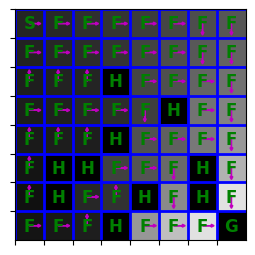

In [45]:
draw_policy(mdp, state_values_pi)

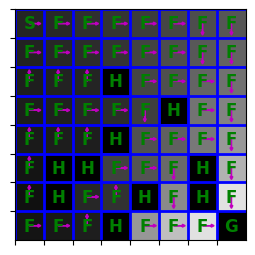

In [46]:
draw_policy(mdp, state_values_vi)

Вектора состояний похожи, и если выбирать политику одинаково, то будет одинаковый итог.

Вывод: Policy itertion сходится быстрей, чем value itertion, и результат по точности не уступает Value Iteration, а даже превосходит его, потому что выбивает среднюю награду больше при большем числе шагов.(у меня так получилось что при 100 шагах совсем плохо получается), а при 1000 стратегия получает хороший reward. Те по числу итераций value_iteration выигрывает значительно. Связано это вероятно, что оптимальных политик несколько и есть более рискованные и менее рискованные изза slip_chance.

## Policy iteration convergence (3 pts)

**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

We can define another Bellman operator:

$$(T_{\pi}V)(s) = \mathbb{E}_{r, s'|s, a = \pi(s)}\left[r + \gamma V(s')\right]$$

And rewrite policy iteration algorithm in operator form:


---

Initialize $\pi_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Solve $V_k = T_{\pi_k}V_k$   

&nbsp;&nbsp;&nbsp;&nbsp; Select $\pi_{k+1}$ s.t. $T_{\pi_{k+1}}V_k = TV_k$ 

**end for**


To prove convergence of the algorithm we need to prove two properties: contraction an monotonicity.

#### Monotonicity (0.5 pts)

For all $V, U$ if $V(s) \le U(s)$   $\forall s \in \mathcal{S}$ then $(T_\pi V)(s) \le (T_\pi U)(s)$   $\forall s \in  \mathcal{S}$

**Доказательство:**

$a=\pi(s); T_{\pi}V = R(s, a) + \gamma\sum_{s'\in S}P(s'|s, a) * V(s'); T_{\pi}U = R(s, a) + \gamma\sum_{s' \in S}P(s'|s, a)U(s')$, тогда получим, что $T_{\pi}U- T_{\pi}V = \gamma\sum{P(s'|s,a)(U(s')-V(s'))}$, по условию U(s') >= V(s'), тогда $T_{\pi}(U) - T_{\pi}(V) >= 0$ ч.т.д.

#### Contraction (1 pts)

$$
||T_\pi V - T_\pi U||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

**Доказательство:**

$\|T_\pi(V) - T_\pi(U)\| = |\gamma \sum P(s'|s,a)(V(s') - U(s'))| \leq \gamma \sum P(s'|s,a)|V(s')-U(s'), \forall s \in S: |T(V)(s) - T(U)(s)| \leq \|T(V)-T(U)\|_{\infty}$, 

тогда напишем разность через норму: 

$\|T_\pi(V)(s) - T_\pi(U)(s)\| = |\gamma \|V-U\|_{\infty} \sum P(s'|s,a)|=\gamma \|V-U\|_{\infty}$, 
где сумма = 1, тк по всем состояниям из текущего по текущим действиям.

Тк s было произвольным, то $\|T_\pi(V) - T_\pi(U)\|_{\infty}\leq \gamma \|V-U\|_{\infty}$ ч.т.д.

#### Convergence (1.5 pts)

Prove that there exists iteration $k_0$ such that $\pi_k = \pi^*$ for all $k \ge k_0$

**Доказательство:**

1. докажем $V_k \leq V_{k+1}$, тк у нас $T(V_k)$ - всегда берет максимальное действие, то $T(V_k) >= T_{\pi_k}(V_k)$, тк политика может быть не оптимальной, при этом по нашему алгоритму $V_k = T_{\pi}(V_k), T_{\pi_{k+1}}(V_k)=T(V_k), T_{\pi_{k+1}}(V_k) = T(V_k) >= T_{\pi_k}(V_k) = V_k$, то есть мы выбираем следующую политику по оптимальному состоянию текущей. \
Возможно политика не обновится, и нам тогда надо чтобы улучшить V сделать еще какое-то число шагов.\
$T_{\pi_{k+1}}(V_k) = T(V_k) >= T_{\pi_k}(V_k) = V_k \to T^2_{\pi_{k+1}}(V_{k}) >= V_k$, кроме того мы знаем, что $T_{\pi_{k+1}}(V_k) = T(V_k)$, а значит по свойству доказанному на алгоритм VI, это сжимающий оператор, значит в пределе мы получим $V_{k+1} >= V_k$. ТЕ на каждой итерации ценность улучшается.

2. у нас количество разных политик конечно, тк состояний и действий конечно, поэтому мы когда-то остановимся

3. тк политик конечно число и V не убывает, то наступит момент когда $V_{k_0 + 1} = V_{k_0}$, тогда сделаем итерации алгоритма $V_{k_0 + 1} = T_{\pi_{k_0+1}}(V_{k_0+1})$, заменяя $V_{k_0} = T_{\pi_{k_0+1}}(V_{k_0})=TV_{k_0}$, те получили уравнение белмана, которое решали для VI, и тогда оно для нас становится неподвижной точкой и на этой итерации нашли неизменяемую политику, значит нашли $\pi^*$, как в доказательстве VI.